In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/DoAnNganh/DuLieu/credit_risk_dataset.csv')

df = df.rename(columns={
    'person_age': 'Age', 'person_income': 'Income', 'person_home_ownership':'Home',
    'person_emp_length': 'EmpLength', 'loan_intent':'Intent', 'loan_grade':'Grade',
    'loan_amnt':'Amount', 'loan_int_rate':'Rate', 'loan_status':'Status',
    'loan_percent_income':'PercentIncome', 'cb_person_default_on_file':'DefaultHist',
    'cb_person_cred_hist_length':'CredHist'
})

df.insert(0, 'PersonID', ['PER_' + str(i).zfill(5) for i in range(1, len(df) + 1)])
df = df.drop_duplicates(subset=['PersonID'])

df = df.dropna(subset=['EmpLength']).copy()
df['Rate'] = df['Rate'].fillna(df.groupby('Grade')['Rate'].transform('median'))

for col in ['Home', 'Intent', 'Grade', 'DefaultHist']:
    df[col] = df[col].astype(str).str.strip().str.upper()

df_clean = df[
    (df['Age'] >= 18) & (df['Age'] <= 100) &
    (df['EmpLength'] < df['Age']) &
    (df['Income'] > 0) &
    (df['Amount'] > 0) &
    (df['PercentIncome'] > 0) & (df['PercentIncome'] < 1) &
    (df['CredHist'] <= df['Age'])
].copy()

df_clean['Income'] = df_clean['Income'].astype(float)
df_clean['Amount'] = df_clean['Amount'].astype(float)

print("✅ ĐÃ LÀM SẠCH DỮ LIỆU THÀNH CÔNG!")
print(f"-> Tổng số dòng hợp lệ giữ lại: {len(df_clean)}")

Mounted at /content/drive
✅ ĐÃ LÀM SẠCH DỮ LIỆU THÀNH CÔNG!
-> Tổng số dòng hợp lệ giữ lại: 31671


=== MA TRẬN TƯƠNG QUAN (XEM BIẾN NÀO ẢNH HƯỞNG ĐẾN NỢ XẤU) ===
Status           1.0000
PercentIncome    0.3797
Rate             0.3379
Amount           0.1121
CredHist        -0.0166
Age             -0.0218
EmpLength       -0.0859
Income          -0.1741
Name: Status, dtype: float64
------------------------------------------------------------


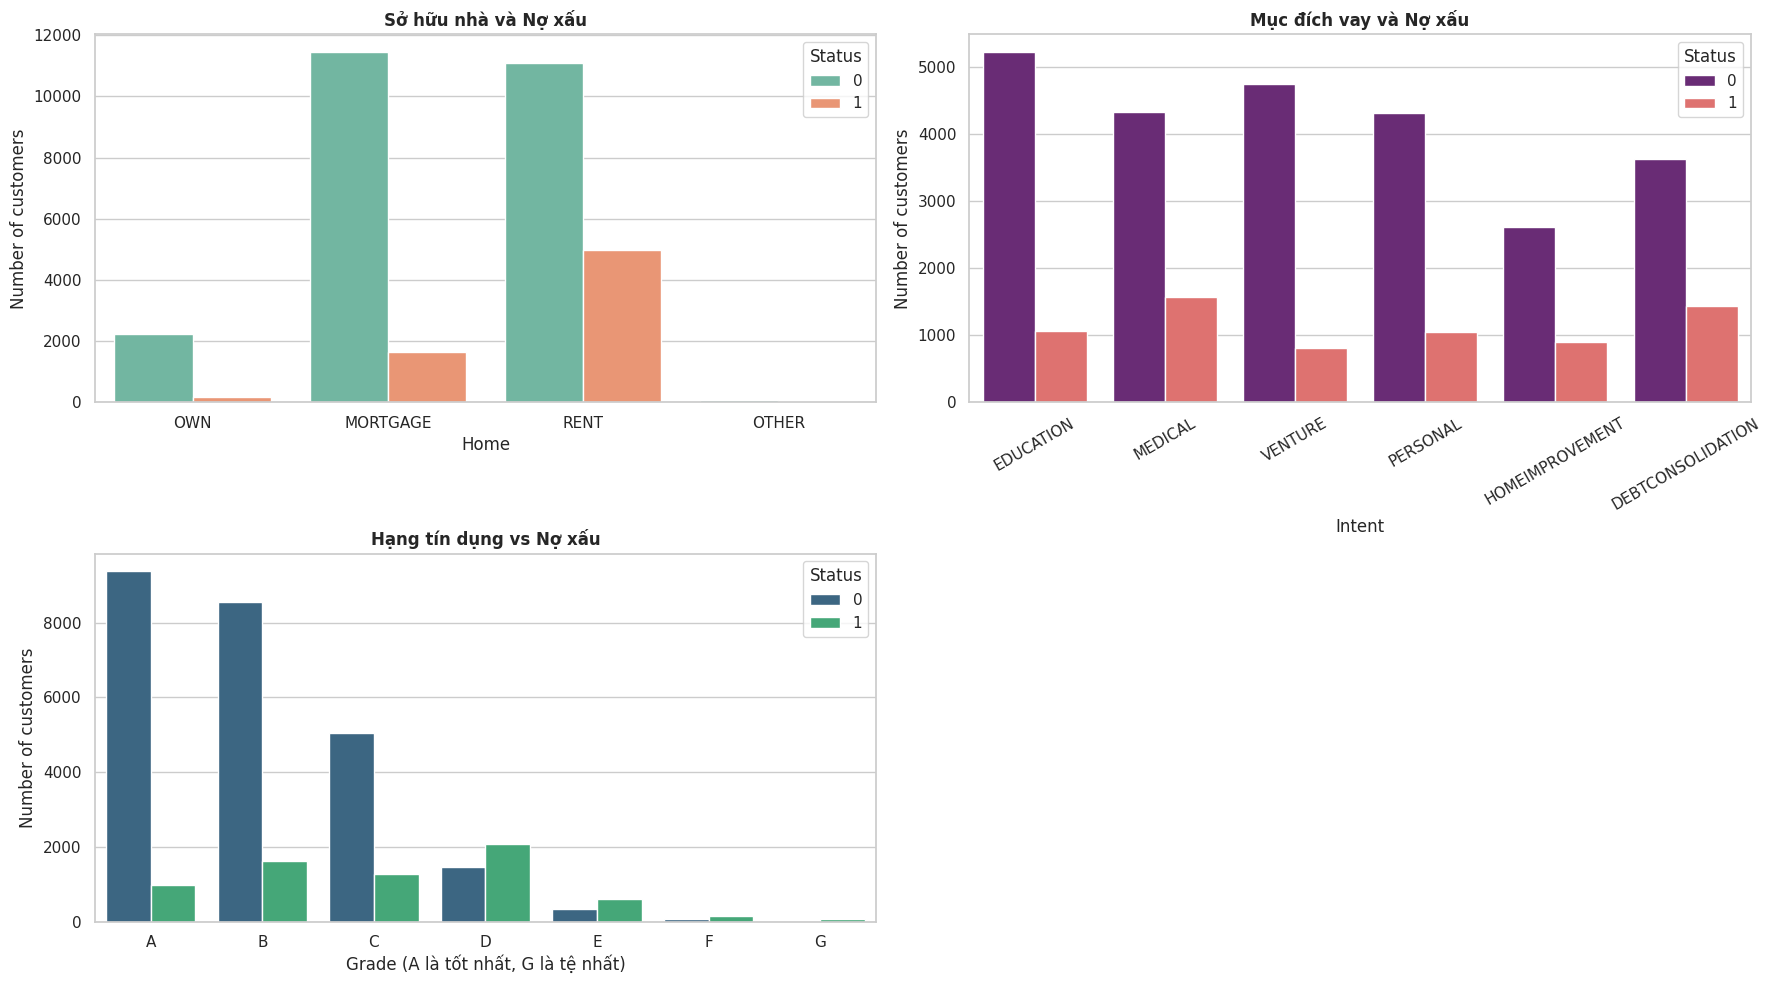

/tmp/ipykernel_1340/1063569808.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['Income'] < 200000], x='Status', y='Income', palette='Set1')
/tmp/ipykernel_1340/1063569808.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Status', y='Amount', palette='PuBu')


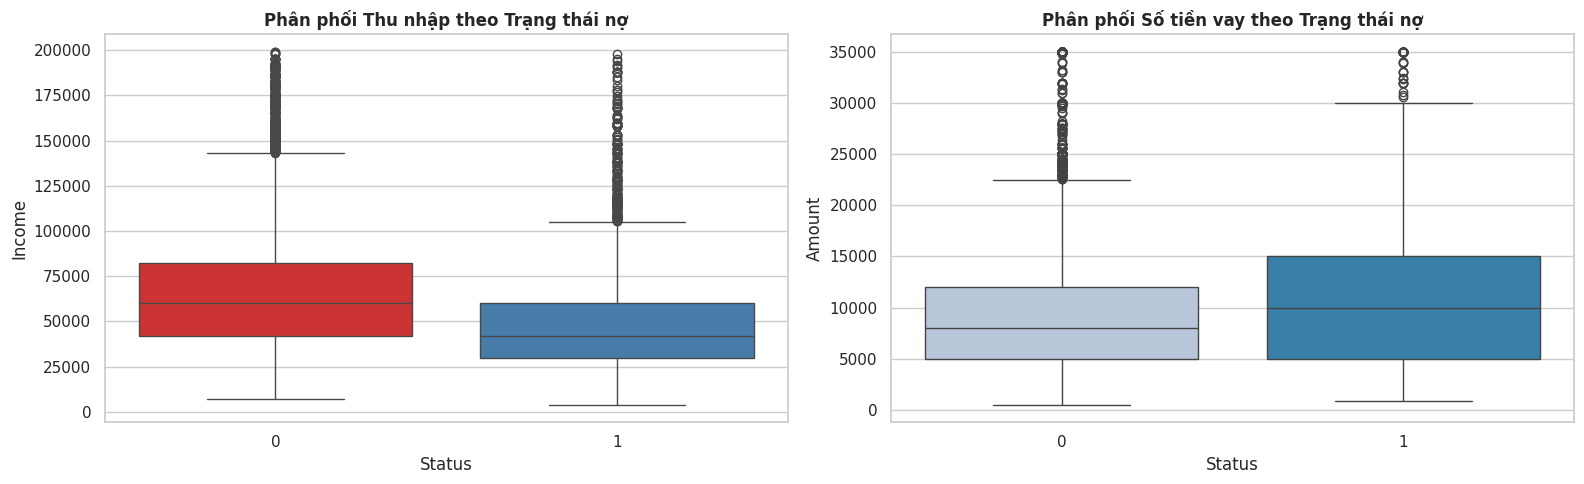

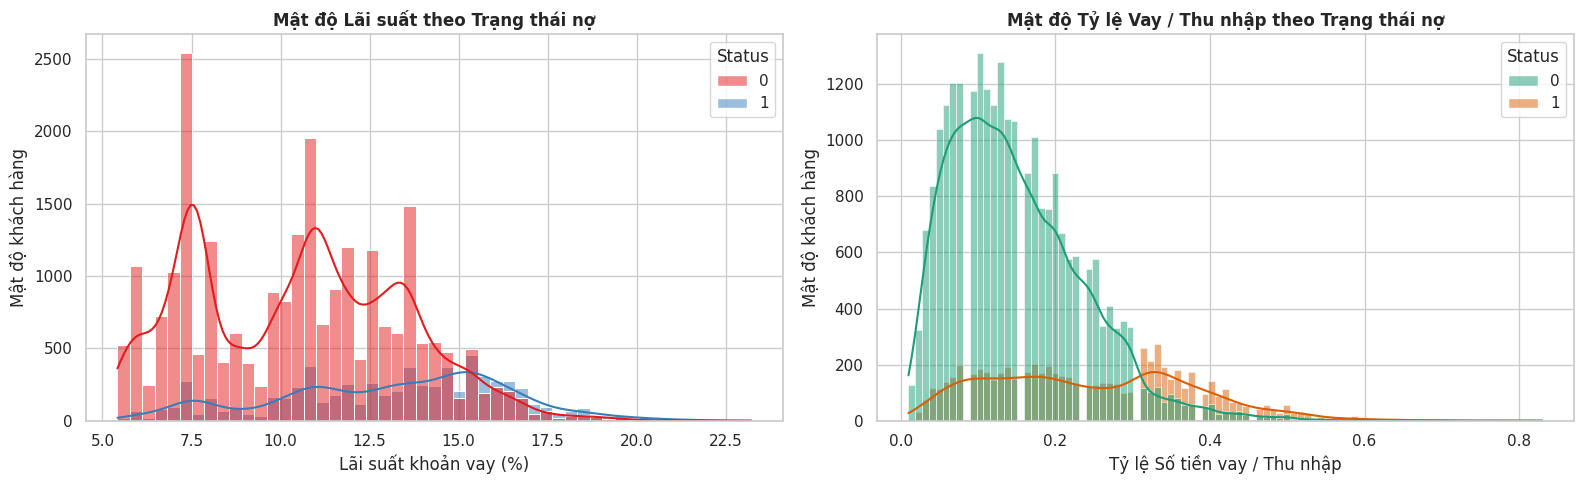

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# BƯỚC 3: KHÁM PHÁ DỮ LIỆU (EDA - EXPLORATORY DATA ANALYSIS)
print("=== MA TRẬN TƯƠNG QUAN (XEM BIẾN NÀO ẢNH HƯỞNG ĐẾN NỢ XẤU) ===")
correlation_matrix = df_clean.corr(numeric_only=True)
print(round(correlation_matrix['Status'].sort_values(ascending=False), 4))
print("-" * 60)

# --- BIỂU ĐỒ 1: MỐI QUAN HỆ GIỮA CÁC BIẾN PHÂN LOẠI VÀ NỢ XẤU ---
plt.figure(figsize=(18, 10))

# 1. Biểu đồ Sở hữu nhà
plt.subplot(2, 2, 1)
sns.countplot(data=df_clean, x='Home', hue='Status', palette='Set2')
plt.title('Sở hữu nhà và Nợ xấu', fontsize=12, fontweight='bold')
plt.xlabel('Home')
plt.ylabel('Number of customers')

# 2. Biểu đồ Mục đích vay
plt.subplot(2, 2, 2)
sns.countplot(data=df_clean, x='Intent', hue='Status', palette='magma')
plt.xticks(rotation=30)
plt.title('Mục đích vay và Nợ xấu', fontsize=12, fontweight='bold')
plt.xlabel('Intent')
plt.ylabel('Number of customers')

# 3. Biểu đồ Hạng tín dụng
plt.subplot(2, 2, 3)
sns.countplot(data=df_clean, x='Grade', hue='Status', order=sorted(df_clean['Grade'].unique()), palette='viridis')
plt.title('Hạng tín dụng vs Nợ xấu', fontsize=12, fontweight='bold')
plt.xlabel('Grade (A là tốt nhất, G là tệ nhất)')
plt.ylabel('Number of customers')

plt.tight_layout()
plt.show()

# --- BIỂU ĐỒ 2: PHÂN PHỐI THU NHẬP VÀ SỐ TIỀN VAY ---
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean[df_clean['Income'] < 200000], x='Status', y='Income', palette='Set1')
plt.title('Phân phối Thu nhập theo Trạng thái nợ', fontsize=12, fontweight='bold')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, x='Status', y='Amount', palette='PuBu')
plt.title('Phân phối Số tiền vay theo Trạng thái nợ', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- BIỂU ĐỒ 3: MẬT ĐỘ LÃI SUẤT VÀ TỶ LỆ VAY/THU NHẬP ---
plt.figure(figsize=(16, 5))

# 1. Histplot Lãi suất bên trái
plt.subplot(1, 2, 1)
sns.histplot(data=df_clean, x='Rate', hue='Status', kde=True, multiple="layer", palette='Set1', alpha=0.5)
plt.title('Mật độ Lãi suất theo Trạng thái nợ', fontsize=12, fontweight='bold')
plt.xlabel('Lãi suất khoản vay (%)')
plt.ylabel('Mật độ khách hàng')

# 2. Histplot Tỷ lệ Vay/Thu nhập bên phải
plt.subplot(1, 2, 2)
sns.histplot(data=df_clean, x='PercentIncome', hue='Status', kde=True, multiple="layer", palette='Dark2', alpha=0.5)
plt.title('Mật độ Tỷ lệ Vay / Thu nhập theo Trạng thái nợ', fontsize=12, fontweight='bold')
plt.xlabel('Tỷ lệ Số tiền vay / Thu nhập')
plt.ylabel('Mật độ khách hàng')

plt.tight_layout()
plt.show()

In [ ]:
# BƯỚC 4: BIẾN ĐỔI DỮ LIỆU (DATA TRANSFORMATION) - FEATURE ENGINEERING
df_features = df_clean.copy()

age_bins = [0, 25, 40, 60, 100]
age_labels = ['18-25', '26-40', '41-60', 'ABOVE 60']
df_features['Age_Group'] = pd.cut(df_features['Age'], bins=age_bins, labels=age_labels)

df_features['Income_Group'] = pd.qcut(df_features['Income'], q=3, labels=['LOW INCOME', 'MEDIUM INCOME', 'HIGH INCOME'])

financial_bins = [0, 0.15, 0.35, 1.0]
financial_labels = ['SAFE (<15%)', 'WARNING (15-35%)', 'HIGH RISK (>35%)']
df_features['Loan_Burden'] = pd.cut(df_features['PercentIncome'], bins=financial_bins, labels=financial_labels)

df_features.to_csv('/content/drive/MyDrive/DoAnNganh/DuLieu/credit_risk_for_powerbi.csv', index=False)
print("✅ ĐÃ XUẤT FILE DẠNG CHỮ CHO POWER BI THÀNH CÔNG!")
print("-> Đường dẫn: /content/drive/MyDrive/DoAnNganh/DuLieu/credit_risk_for_powerbi.csv")

✅ ĐÃ XUẤT FILE DẠNG CHỮ CHO POWER BI THÀNH CÔNG!
-> Đường dẫn: /content/drive/MyDrive/DoAnNganh/DuLieu/credit_risk_for_powerbi.csv


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. TẠO BẢNG DỮ LIỆU CHUẨN TRỊ CHO ML/AI
df_ai = df_features.copy()

cols_to_drop_for_ai = ['PersonID', 'Age_Group', 'Income_Group', 'Loan_Burden']
df_ai = df_ai.drop(columns=[col for col in cols_to_drop_for_ai if col in df_ai.columns], axis=1)

# 2. MÃ HÓA BIẾN (ENCODING)
df_ai['Grade'] = df_ai['Grade'].map({'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7})
nominal_and_binary = ['Home', 'Intent', 'DefaultHist']
df_ai = pd.get_dummies(df_ai, columns=nominal_and_binary, drop_first=True, dtype=int)

df_ai.to_csv('/content/drive/MyDrive/DoAnNganh/DuLieu/credit_risk_processed_for_AI.csv', index=False)

# 3. CHIA TẬP TRAIN / TEST (80% - 20%)
X = df_ai.drop('Status', axis=1)
y = df_ai['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. CHUẨN HÓA MIN-MAX SCALING (CHỐNG RÒ RỈ DỮ LIỆU)
numeric_cols = ['Age', 'Income', 'EmpLength', 'Amount', 'Rate', 'PercentIncome', 'CredHist']
scaler = MinMaxScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("✅ ĐÃ CHUẨN BỊ DỮ LIỆU AI XONG (KHÔNG BỊ DATA LEAKAGE & ĐA CỘNG TUYẾN)!")
print(f"-> Kích thước tập huấn luyện (X_train): {X_train.shape}")
print(f"-> Kích thước tập kiểm tra (X_test): {X_test.shape}")

✅ ĐÃ CHUẨN BỊ DỮ LIỆU AI XONG (KHÔNG BỊ DATA LEAKAGE & ĐA CỘNG TUYẾN)!
-> Kích thước tập huấn luyện (X_train): (25336, 17)
-> Kích thước tập kiểm tra (X_test): (6335, 17)


=== KẾT QUẢ MÔ HÌNH LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      4970
           1       0.52      0.78      0.62      1365

    accuracy                           0.80      6335
   macro avg       0.72      0.79      0.74      6335
weighted avg       0.84      0.80      0.81      6335


=== KẾT QUẢ MÔ HÌNH RANDOM FOREST (NÂNG CẤP) ===
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      4970
           1       0.84      0.75      0.79      1365

    accuracy                           0.92      6335
   macro avg       0.89      0.86      0.87      6335
weighted avg       0.91      0.92      0.91      6335



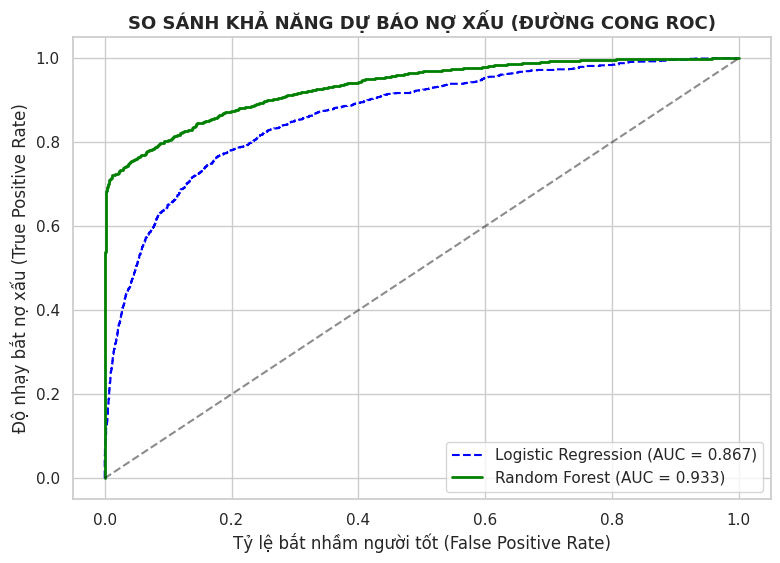

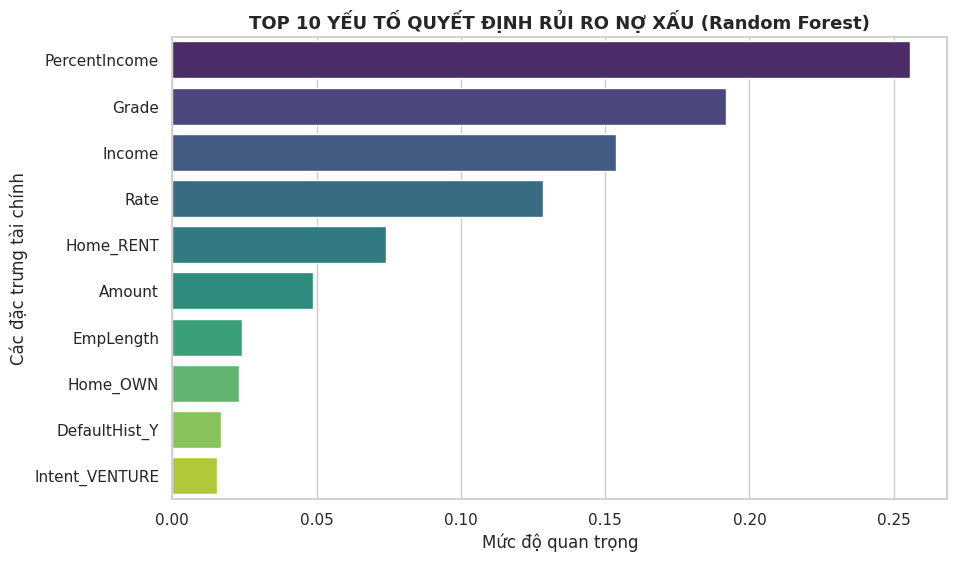

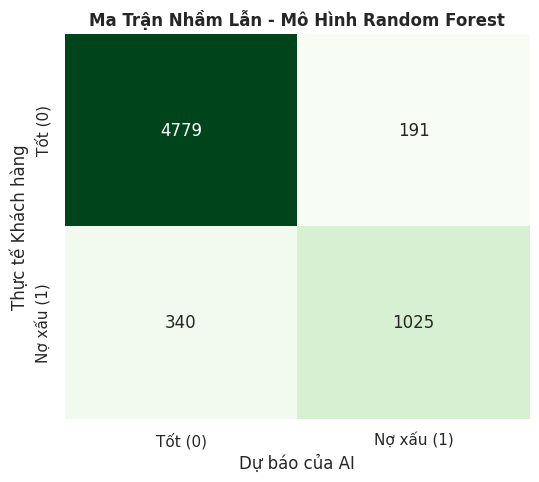

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# BƯỚC 5: MÔ HÌNH HÓA (DATA MODELING)
# Mô hình 1: Logistic Regression (Baseline - Tính diễn giải cao)
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Mô hình 2: Random Forest (Nâng cấp - Khả năng bắt mạch dữ liệu phi tuyến tính tốt hơn)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# BƯỚC 6: ĐÁNH GIÁ MÔ HÌNH (MODEL EVALUATION)
print("=== KẾT QUẢ MÔ HÌNH LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_log))
print("\n=== KẾT QUẢ MÔ HÌNH RANDOM FOREST (NÂNG CẤP) ===")
print(classification_report(y_test, y_pred_rf))

# --- ĐƯỜNG CONG ROC SO SÁNH 2 MÔ HÌNH ---
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(9, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})', color='blue', linestyle='--')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='green', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('SO SÁNH KHẢ NĂNG DỰ BÁO NỢ XẤU (ĐƯỜNG CONG ROC)', fontsize=13, fontweight='bold')
plt.xlabel('Tỷ lệ bắt nhầm người tốt (False Positive Rate)')
plt.ylabel('Độ nhạy bắt nợ xấu (True Positive Rate)')
plt.legend(loc='lower right', fontsize=11)
plt.show()

# ---  TOP 10 YẾU TỐ ẢNH HƯỞNG ĐẾN NỢ XẤU (RANDOM FOREST) ---
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance.head(10), palette='viridis', hue='Feature', legend=False)
plt.title('TOP 10 YẾU TỐ QUYẾT ĐỊNH RỦI RO NỢ XẤU (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Các đặc trưng tài chính')
plt.show()

# ---  MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Tốt (0)', 'Nợ xấu (1)'],
            yticklabels=['Tốt (0)', 'Nợ xấu (1)'])
plt.title('Ma Trận Nhầm Lẫn - Mô Hình Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Dự báo của AI')
plt.ylabel('Thực tế Khách hàng')
plt.show()